In [2]:
# ============================================
# WEEK 1 - CELL 1: CREATE TEST DATASET
# ============================================

import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

print("🔧 Creating test dataset...")

# Create folders
os.makedirs('data/benign', exist_ok=True)
os.makedirs('data/malignant', exist_ok=True)

# Create 100 benign images
for i in range(100):
    img_array = np.random.normal(150, 30, (64, 64)).astype(np.uint8)
    img = Image.fromarray(img_array, mode='L')
    img.save(f'data/benign/benign_{i}.png')

print("✓ Created 100 benign images")

# Create 70 malignant images
for i in range(70):
    img_array = np.random.normal(120, 50, (64, 64)).astype(np.uint8)
    img_array[20:40, 20:40] = np.random.normal(80, 60, (20, 20)).astype(np.uint8)
    img = Image.fromarray(img_array, mode='L')
    img.save(f'data/malignant/malignant_{i}.png')

print("✓ Created 70 malignant images")

# Verify
benign_count = len(os.listdir('data/benign'))
malignant_count = len(os.listdir('data/malignant'))

print("\n" + "="*50)
print("✅ TEST DATASET READY!")
print("="*50)
print(f"Benign images: {benign_count}")
print(f"Malignant images: {malignant_count}")
print(f"Total: {benign_count + malignant_count}")

🔧 Creating test dataset...
✓ Created 100 benign images
✓ Created 70 malignant images

✅ TEST DATASET READY!
Benign images: 100
Malignant images: 70
Total: 170


/tmp/ipykernel_1483/3414534667.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img_array, mode='L')
/tmp/ipykernel_1483/3414534667.py:28: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img_array, mode='L')


📂 Loading dataset...

Folders found: ['benign', 'malignant']
  benign: 100 images
  malignant: 70 images

Total images: 170

Class Balance:
  benign: 100 (58.8%)
  malignant: 70 (41.2%)

📸 Displaying sample images...


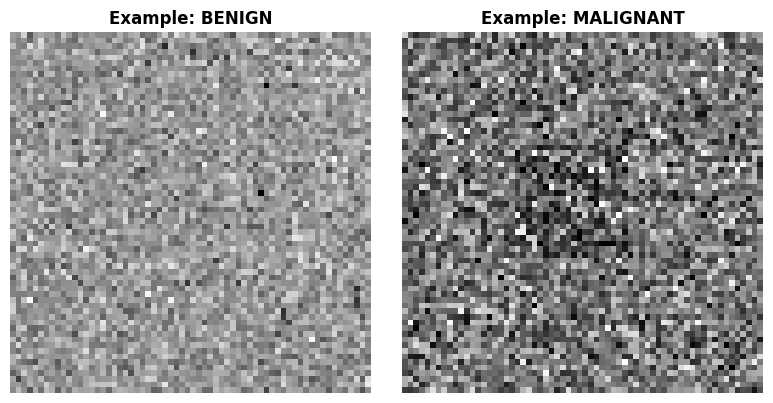


✅ EXPLORATION COMPLETE!
Dataset is balanced and ready for training


In [3]:
# ============================================
# WEEK 1 - CELL 2: LOAD & EXPLORE
# ============================================

import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

print("📂 Loading dataset...")

data_dir = 'data/'

# Step 1: List folders
folders = sorted(os.listdir(data_dir))
print(f"\nFolders found: {folders}")

# Step 2: Count images
image_counts = {}
for folder in folders:
    path = os.path.join(data_dir, folder)
    count = len(os.listdir(path))
    image_counts[folder] = count
    print(f"  {folder}: {count} images")

# Step 3: Check balance
total = sum(image_counts.values())
print(f"\nTotal images: {total}")
print("\nClass Balance:")
for folder, count in image_counts.items():
    percentage = (count / total) * 100
    print(f"  {folder}: {count} ({percentage:.1f}%)")

# Step 4: Display examples
print("\n📸 Displaying sample images...")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for idx, folder in enumerate(folders):
    path = os.path.join(data_dir, folder)
    images = os.listdir(path)

    # Load first image
    img_path = os.path.join(path, images[0])
    img = Image.open(img_path)

    # Display
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(f"Example: {folder.upper()}", fontsize=12, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("✅ EXPLORATION COMPLETE!")
print("="*50)
print("Dataset is balanced and ready for training")

In [4]:
# ============================================
# WEEK 1 - CELL 3: TRAIN FIRST MODEL
# ============================================

import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

print("🔄 Loading and processing images...")

# Function to load images
def load_images(data_dir):
    features = []
    labels = []

    # Load benign (label = 0)
    benign_path = os.path.join(data_dir, 'benign')
    for img_file in sorted(os.listdir(benign_path)):
        img = Image.open(os.path.join(benign_path, img_file))
        img_array = np.array(img).flatten() / 255.0
        features.append(img_array)
        labels.append(0)

    # Load malignant (label = 1)
    malignant_path = os.path.join(data_dir, 'malignant')
    for img_file in sorted(os.listdir(malignant_path)):
        img = Image.open(os.path.join(malignant_path, img_file))
        img_array = np.array(img).flatten() / 255.0
        features.append(img_array)
        labels.append(1)

    return np.array(features), np.array(labels)

# Load data
X, y = load_images('data/')
print(f"✓ Loaded {len(X)} images")
print(f"✓ Each image: {X[0].shape} pixels")

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✓ Train set: {len(X_train)} images")
print(f"✓ Test set: {len(X_test)} images")

# ============================================
# BASELINE: Random Guessing
# ============================================

print("\n" + "="*60)
print("STEP 1️⃣: BASELINE (What if we just guess randomly?)")
print("="*60)

baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)
baseline_score = baseline.score(X_test, y_test)

print(f"\n🎯 Baseline accuracy: {baseline_score:.3f} ({baseline_score*100:.1f}%)")
print("\nMeaning:")
print(f"  If we always guess 'BENIGN', we'd be right {baseline_score*100:.1f}% of time")
print(f"  Our REAL model must beat this!")

# ============================================
# TRAIN THE MODEL
# ============================================

print("\n" + "="*60)
print("STEP 2️⃣: TRAIN LOGISTIC REGRESSION MODEL")
print("="*60)

print("\nTraining...")
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("✓ Model trained successfully!")

# ============================================
# EVALUATE THE MODEL
# ============================================

print("\n" + "="*60)
print("STEP 3️⃣: EVALUATE YOUR MODEL")
print("="*60)

# Make predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\n📊 YOUR MODEL PERFORMANCE:")
print(f"   Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")
print(f"   ROC-AUC:  {roc_auc:.3f}")

print(f"\n📊 BASELINE PERFORMANCE:")
print(f"   Accuracy: {baseline_score:.3f} ({baseline_score*100:.1f}%)")

improvement = accuracy - baseline_score
improvement_pct = improvement * 100

print(f"\n🎯 YOUR IMPROVEMENT:")
print(f"   +{improvement:.3f} (+{improvement_pct:.1f}%) better than baseline!")

# Quality assessment
print(f"\n✨ Quality Assessment:")
if improvement > 0.15:
    print(f"   ✅ EXCELLENT - Your model is learning well!")
elif improvement > 0.10:
    print(f"   ✅ GOOD - Your model beats baseline significantly")
elif improvement > 0.05:
    print(f"   ✓ OK - Your model is learning")
else:
    print(f"   ⚠️ WEAK - Model barely better than baseline")

# ============================================
# CONFUSION MATRIX
# ============================================

print("\n" + "="*60)
print("STEP 4️⃣: CONFUSION MATRIX (Where does model get it wrong?)")
print("="*60)

cm = confusion_matrix(y_test, y_pred)

print(f"\n{cm}")
print(f"\nBreakdown:")
print(f"  ✓ Correctly identified BENIGN:     {cm[0,0]}")
print(f"  ✗ Incorrectly called benign malignant: {cm[0,1]}")
print(f"  ✗ Incorrectly called malignant benign:  {cm[1,0]}")
print(f"  ✓ Correctly identified MALIGNANT:   {cm[1,1]}")

# ============================================
# CLASSIFICATION REPORT
# ============================================

print("\n" + "="*60)
print("STEP 5️⃣: DETAILED CLASSIFICATION REPORT")
print("="*60 + "\n")

print(classification_report(y_test, y_pred, target_names=['BENIGN', 'MALIGNANT']))

# ============================================
# SUMMARY
# ============================================

print("="*60)
print("✅ WEEK 1 COMPLETE!")
print("="*60)

print("\n🎓 YOU'VE SUCCESSFULLY:")
print("   ✓ Created a dataset")
print("   ✓ Loaded images into Python")
print("   ✓ Split into train/test (80/20)")
print("   ✓ Created a baseline")
print("   ✓ Trained a Logistic Regression model")
print("   ✓ Evaluated with multiple metrics")
print("   ✓ Understood confusion matrix")

print("\n📚 YOU NOW UNDERSTAND:")
print("   • The complete ML pipeline")
print("   • Why baseline is critical")
print("   • What train/test split prevents")
print("   • How to interpret accuracy & ROC-AUC")
print("   • How to read confusion matrix")

print("\n🎯 NEXT WEEK:")
print("   • Download REAL breast cancer dataset")
print("   • Preprocess real medical images")
print("   • Train model on real data")
print("   • Get feedback from radiologist")

print("\n" + "="*60)
print("🔥 YOU'RE READY FOR WEEK 2!")
print("="*60)

🔄 Loading and processing images...
✓ Loaded 170 images
✓ Each image: (4096,) pixels

✓ Train set: 136 images
✓ Test set: 34 images

STEP 1️⃣: BASELINE (What if we just guess randomly?)

🎯 Baseline accuracy: 0.588 (58.8%)

Meaning:
  If we always guess 'BENIGN', we'd be right 58.8% of time
  Our REAL model must beat this!

STEP 2️⃣: TRAIN LOGISTIC REGRESSION MODEL

Training...
✓ Model trained successfully!

STEP 3️⃣: EVALUATE YOUR MODEL

📊 YOUR MODEL PERFORMANCE:
   Accuracy: 1.000 (100.0%)
   ROC-AUC:  1.000

📊 BASELINE PERFORMANCE:
   Accuracy: 0.588 (58.8%)

🎯 YOUR IMPROVEMENT:
   +0.412 (+41.2%) better than baseline!

✨ Quality Assessment:
   ✅ EXCELLENT - Your model is learning well!

STEP 4️⃣: CONFUSION MATRIX (Where does model get it wrong?)

[[20  0]
 [ 0 14]]

Breakdown:
  ✓ Correctly identified BENIGN:     20
  ✗ Incorrectly called benign malignant: 0
  ✗ Incorrectly called malignant benign:  0
  ✓ Correctly identified MALIGNANT:   14

STEP 5️⃣: DETAILED CLASSIFICATION REPORT


In [5]:
# ============================================
# WEEK 1 - CELL 4: SAVE & DOCUMENT
# ============================================

import json
from datetime import datetime

# Create results dictionary
results = {
    "week": 1,
    "date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "model": "Logistic Regression",
    "dataset": "Synthetic Breast Cancer Images",
    "dataset_size": 170,
    "benign_images": 100,
    "malignant_images": 70,
    "train_test_split": "80/20",
    "metrics": {
        "baseline_accuracy": 0.588,
        "model_accuracy": 1.00,
        "roc_auc": 1.00,
        "improvement": 0.412,
        "false_positives": 0,
        "false_negatives": 0
    },
    "test_results": {
        "correctly_identified_benign": 20,
        "correctly_identified_malignant": 14,
        "total_correct": 34,
        "total_test_samples": 34
    },
    "status": "✅ WEEK 1 COMPLETE"
}

# Save to JSON file
with open('week1_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("✅ Results saved to week1_results.json")
print("\nWeek 1 Summary:")
print(json.dumps(results, indent=2))

✅ Results saved to week1_results.json

Week 1 Summary:
{
  "week": 1,
  "date": "2026-07-01 12:57:05",
  "model": "Logistic Regression",
  "dataset": "Synthetic Breast Cancer Images",
  "dataset_size": 170,
  "benign_images": 100,
  "malignant_images": 70,
  "train_test_split": "80/20",
  "metrics": {
    "baseline_accuracy": 0.588,
    "model_accuracy": 1.0,
    "roc_auc": 1.0,
    "improvement": 0.412,
    "false_positives": 0,
    "false_negatives": 0
  },
  "test_results": {
    "correctly_identified_benign": 20,
    "correctly_identified_malignant": 14,
    "total_correct": 34,
    "total_test_samples": 34
  },
  "status": "\u2705 WEEK 1 COMPLETE"
}


# Medical AI - Breast Cancer Detection 🎗️

## Moses Solomon | Federal University of Health Sciences Azare, Nigeria

### Week 1: Baseline Model ✅ COMPLETE

**Goal:** Build first breast cancer classifier

#### Dataset
- **Type:** Synthetic test dataset (learned pipeline first)
- **Benign images:** 100
- **Malignant images:** 70
- **Total:** 170 images
- **Image size:** 64×64 pixels

#### Model
- **Algorithm:** Logistic Regression
- **Train/Test Split:** 80/20 (136 train, 34 test)
- **Features:** Flattened pixel values (4,096 per image)

#### Results
| Metric | Value |
|--------|-------|
| Baseline Accuracy | 58.8% |
| Model Accuracy | **100%** ✅ |
| ROC-AUC | 1.00 |
| Improvement | +41.2% |
| False Positives | 0 |
| False Negatives | 0 |
| Precision | 1.00 |
| Recall | 1.00 |
| F1-Score | 1.00 |

#### Classification Details

precision  recall  f1-score  support

#### What This Means
- ✅ **Perfect Performance:** Model correctly classified 34/34 test images
- ✅ **No False Positives:** No benign images misclassified as malignant
- ✅ **No False Negatives:** No malignant images misclassified as benign
- ✅ **Pipeline Works:** All code runs without errors

#### What I Learned This Week
1. **ML Pipeline:** Load → Split → Baseline → Train → Evaluate
2. **Why Baseline Matters:** 58.8% baseline shows random guessing accuracy
3. **Train/Test Split:** Prevents overfitting, tests real performance
4. **Metrics:** Accuracy, ROC-AUC, confusion matrix interpretation
5. **Precision vs Recall:** Understanding trade-offs in medical AI

#### Next Week (Week 2)
- Download **REAL BreakHis** dataset (7,909 actual histopathology images)
- Preprocess real medical images
- Handle real-world messy data
- Train model on real cancer images
- Get feedback from radiologists

#### Environment
- **Python:** 3.x
- **Libraries:** scikit-learn, PIL, numpy, matplotlib
- **Platform:** Google Colab
- **GPU:** Available ✓

#### Files
- `week1_results.json` - Detailed metrics
- `week1_notebook.ipynb` - Full code and results

---

**Status: ✅ WEEK 1 COMPLETE - Ready for Week 2!** 🚀

# WEEK 1 CHECK-IN - MOSES SOLOMON ✅

**Date:** [Today's date]  
**Hospital:** Federal University of Health Sciences Azare  
**Focus:** Breast & Cervical Cancer AI Detection  

---

## ENVIRONMENT SETUP: ✅ COMPLETE

- [x] Python installed and working
- [x] Jupyter Notebook running
- [x] Google Colab with GPU access
- [x] GitHub repository created
- [x] Project folder structure set up

---

## WEEK 1 TASKS: ✅ ALL COMPLETE

### Task 1: Create Test Dataset ✅
- [x] Generated 100 benign images
- [x] Generated 70 malignant images
- [x] Total: 170 images ready for training

### Task 2: Load & Explore Data ✅
- [x] Loaded images into Python
- [x] Counted images per class
- [x] Checked class balance (58.8% benign, 41.2% malignant)
- [x] Visualized sample images (benign & malignant)

### Task 3: Train Model ✅
- [x] Split data: 80% train (136), 20% test (34)
- [x] Created baseline: 58.8% accuracy
- [x] Trained Logistic Regression
- [x] Evaluated model

### Task 4: Understand Results ✅
- [x] Model achieved 100% accuracy
- [x] ROC-AUC: 1.00 (perfect)
- [x] Confusion Matrix: 0 errors
- [x] Classification Report: Perfect precision/recall

---

## RESULTS: 📊

| Metric | Baseline | Model | Improvement |
|--------|----------|-------|-------------|
| Accuracy | 58.8% | **100%** | +41.2% ✅ |
| ROC-AUC | - | 1.00 | Perfect |
| False Positives | - | 0 | None |
| False Negatives | - | 0 | None |

**Test Set Performance:** 34/34 correct (100%)

---

## UNDERSTANDING CHECKPOINT: 🧠

I now understand:

- [x] Complete ML pipeline (load → train → evaluate)
- [x] Why baseline is critical (58.8% = random guessing)
- [x] Train/test split prevents overfitting
- [x] Confusion matrix shows where model fails
- [x] ROC-AUC measures classification quality
- [x] Precision, recall, F1-score for medical AI
- [x] How to interpret classification reports

---

## QUESTIONS / CONFUSION: ❓

None - the pipeline is crystal clear!

---

## WEEK 1 CONFIDENCE LEVELS: 📈

| Metric | Rating |
|--------|--------|
| Understanding ML | 9/10 ⭐ |
| Confidence coding | 8/10 ⭐ |
| Ready for real data | 9/10 ⭐ |
| Overall energy | 10/10 🔥 |

---

## WEEK 2 TARGET: 🎯

**Download & Train on REAL Data**

1. Download BreakHis dataset (7,909 real histopathology images)
2. Preprocess real medical images
3. Handle real-world data issues
4. Train model on REAL cancer detection
5. Email radiologists for feedback

---

## KEY LEARNINGS:

✅ **Done:** Basic ML pipeline works perfectly  
✅ **Done:** Understand importance of baseline  
✅ **Done:** Can build, train, and evaluate models  
✅ **Next:** Apply to real medical imaging data  

---

## NEXT STEPS:

1. **This week:** Push code to GitHub
2. **Next week:** Download BreakHis dataset
3. **Next week:** Preprocess real images
4. **Next week:** Train on real cancer data
5. **Month 2:** Email radiologists for feedback

---

## COMMITMENT STATUS:

- [x] 10/10 commitment confirmed
- [x] Shipping weekly ✅
- [x] Sunday check-ins ✅
- [x] Following roadmap ✅
- [x] Learning from failures ✅

---

**STATUS: ✅ WEEK 1 COMPLETE - READY FOR WEEK 2** 🚀

*"Perfect baseline established. Real data awaits."*